In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

from src.data.loader import load_and_merge
from src.data.splitter import temporal_split
from src.data.preprocessor import preprocess_train
from src.features.feature_engineer import feature_engineer_train

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
print("Loading data... (bir necha daqiqa)")

df = load_and_merge("train")
train, val = temporal_split(df)
train, prep_artifacts = preprocess_train(train)
train, fe_artifacts = feature_engineer_train(train)

exclude_cols = ["isFraud", "TransactionID", "TransactionDT",
                "card1_addr1", "card_full", "FE_card1_addr1", "FE_card_full"]

feature_cols = [c for c in train.select_dtypes(include=[np.number]).columns
                if c not in exclude_cols]

X = train[feature_cols]
y = train["isFraud"]

print(f"X shape     : {X.shape}")
print(f"y shape     : {y.shape}")
print(f"Fraud rate  : {y.mean()*100:.2f}%")
print(f"Total features: {len(feature_cols)}")

2026-04-22 22:37:13 | INFO     | loader | ==================================================
2026-04-22 22:37:13 | INFO     | loader | LOADING & MERGING: train
2026-04-22 22:37:13 | INFO     | loader | Loading train_transaction.csv...


Loading data... (bir necha daqiqa)


2026-04-22 22:37:20 | INFO     | loader |   train_transaction shape: (590540, 394)
2026-04-22 22:37:20 | INFO     | loader | Loading train_identity.csv...
2026-04-22 22:37:20 | INFO     | loader |   train_identity shape: (144233, 41)
2026-04-22 22:37:20 | INFO     | loader |   Merged shape : (590540, 434)
2026-04-22 22:37:20 | INFO     | loader |   Memory usage : 1984.2 MB
2026-04-22 22:37:20 | INFO     | loader |   Fraud rate   : 3.50%
2026-04-22 22:37:20 | INFO     | loader | LOADING COMPLETE
2026-04-22 22:37:20 | INFO     | loader | ==================================================
2026-04-22 22:37:20 | INFO     | splitter | Starting temporal split...
2026-04-22 22:37:20 | INFO     | splitter | Input shape: (590540, 434)
2026-04-22 22:37:21 | INFO     | splitter | Train shape : (472432, 434) | Date range: 86400 → 12192842
2026-04-22 22:37:21 | INFO     | splitter | Val shape   : (118108, 434)   | Date range: 12192900 → 15811131
2026-04-22 22:37:21 | INFO     | splitter | Train frau

X shape     : (472432, 448)
y shape     : (472432,)
Fraud rate  : 3.51%
Total features: 448


In [3]:
print("Step 1: Correlation filter (threshold=0.95)")

corr_matrix = X.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
X_filtered = X.drop(columns=drop_corr)

print(f"Features before correlation filter : {X.shape[1]}")
print(f"Dropped (corr > 0.95)              : {len(drop_corr)}")
print(f"Features after correlation filter  : {X_filtered.shape[1]}")
print(f"\nDropped columns: {drop_corr[:15]}...")

Step 1: Correlation filter (threshold=0.95)
Features before correlation filter : 448
Dropped (corr > 0.95)              : 73
Features after correlation filter  : 375

Dropped columns: ['C6', 'C7', 'C10', 'C11', 'C14', 'M2', 'M3', 'V11', 'V16', 'V18', 'V22', 'V28', 'V30', 'V32', 'V33']...


Step 2: XGBoost importance (running...)
  Features covering 80% importance: 154
  Features covering 90% importance: 214
  Features covering 95% importance: 254
  Features covering 99% importance: 302


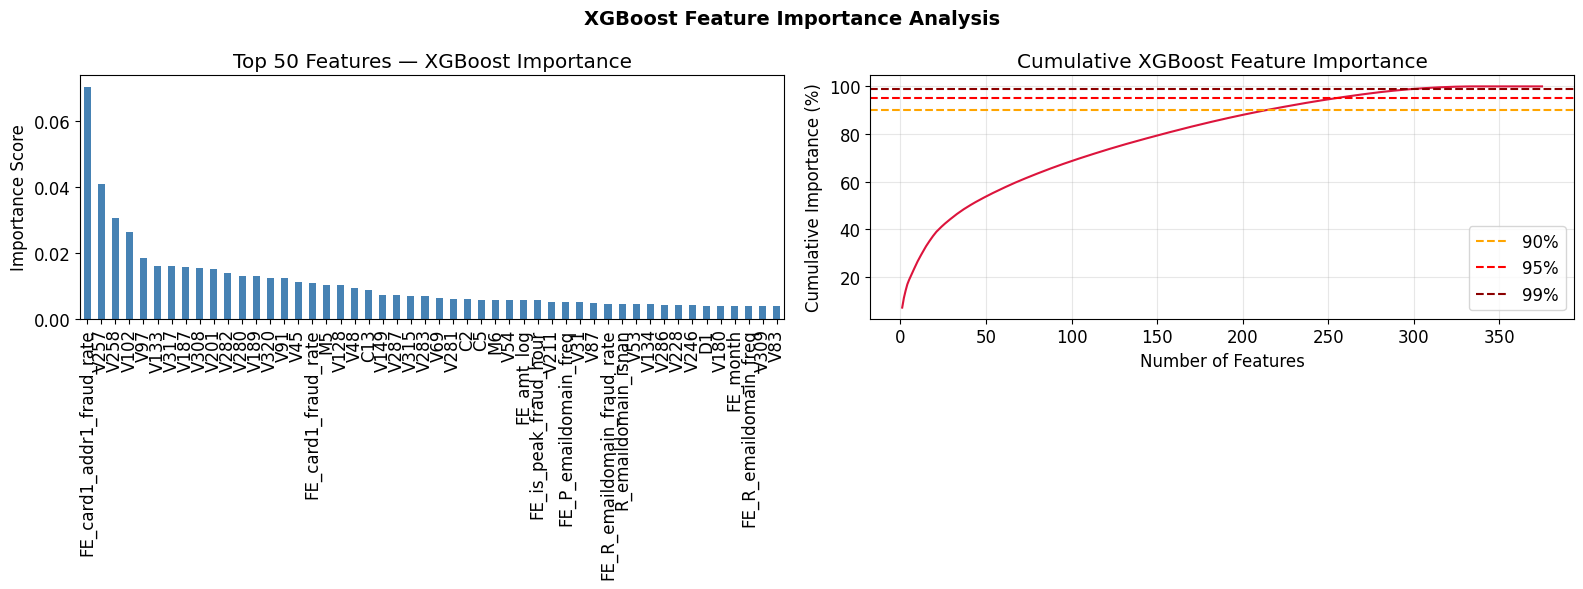


Top 10 XGB features:
FE_card1_addr1_fraud_rate    0.070289
V257                         0.040953
V258                         0.030501
V102                         0.026299
V97                          0.018334
V133                         0.016052
V317                         0.015832
V187                         0.015595
V308                         0.015369
V201                         0.015157
dtype: float32


In [4]:
from xgboost import XGBClassifier

print("Step 2: XGBoost importance (running...)")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=27,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_filtered.fillna(-999), y)

importance = pd.Series(
    xgb.feature_importances_,
    index=X_filtered.columns
).sort_values(ascending=False)

# Cumulative importance
cumulative = importance.cumsum() / importance.sum() * 100

# How many features cover 80%, 90%, 95%
for pct in [80, 90, 95, 99]:
    n = (cumulative <= pct).sum() + 1
    print(f"  Features covering {pct}% importance: {n}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 50 feature importance
importance.head(50).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 50 Features — XGBoost Importance')
axes[0].set_ylabel('Importance Score')
axes[0].tick_params(axis='x', rotation=90)

# Cumulative importance curve
axes[1].plot(range(1, len(cumulative)+1), cumulative.values, color='crimson')
axes[1].axhline(y=90, color='orange', linestyle='--', label='90%')
axes[1].axhline(y=95, color='red',    linestyle='--', label='95%')
axes[1].axhline(y=99, color='darkred',linestyle='--', label='99%')
axes[1].set_title('Cumulative XGBoost Feature Importance')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('XGBoost Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTop 10 XGB features:")
print(importance.head(10))

Step 3: Mutual Information analysis (running...)
  Features covering 80% MI score: 123
  Features covering 90% MI score: 153
  Features covering 95% MI score: 195
  Features covering 99% MI score: 276


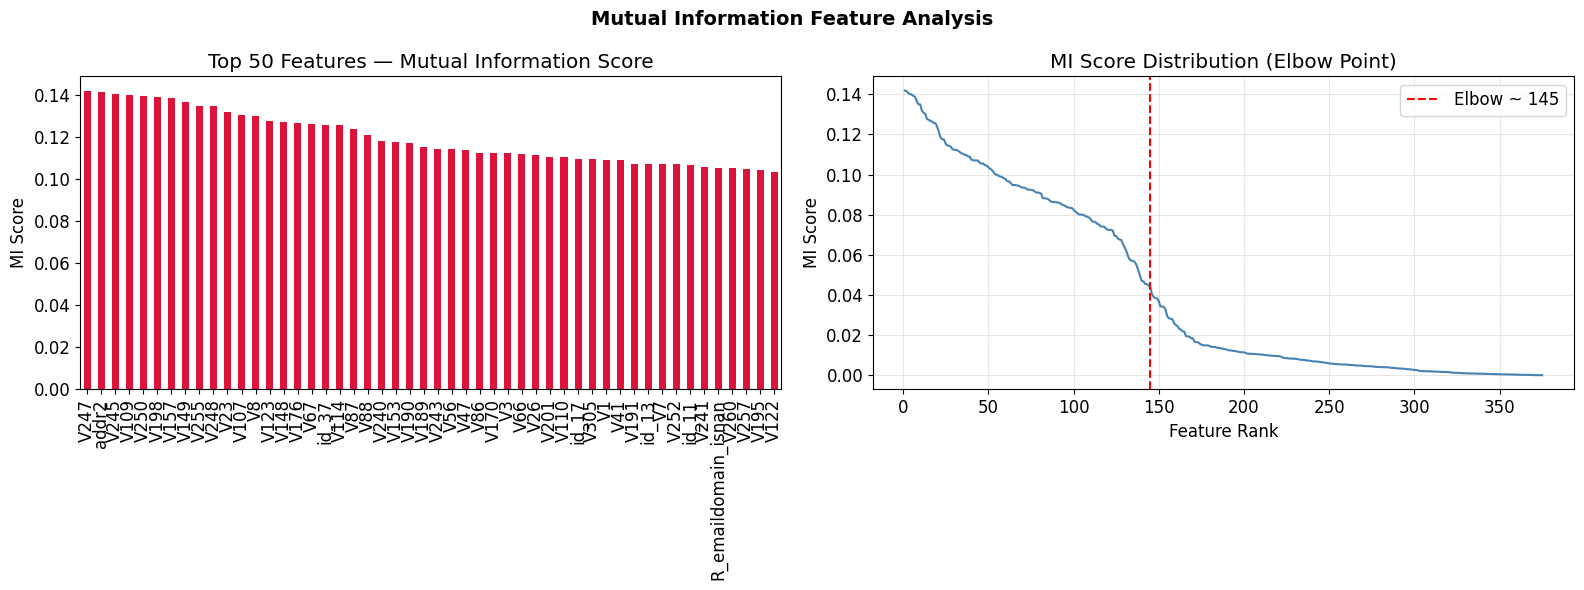


Elbow point detected at: 145 features

Top 10 MI features:
V247     0.141877
addr2    0.141629
V245     0.140637
V109     0.140157
V250     0.139849
V198     0.139239
V157     0.138752
V149     0.136606
V255     0.135021
V248     0.134983
dtype: float64


In [5]:
from sklearn.feature_selection import mutual_info_classif

print("Step 3: Mutual Information analysis (running...)")

mi_scores = mutual_info_classif(
    X_filtered.fillna(-999), y, random_state=42
)
mi_series = pd.Series(
    mi_scores, index=X_filtered.columns
).sort_values(ascending=False)

mi_cumulative = mi_series.cumsum() / mi_series.sum() * 100

for pct in [80, 90, 95, 99]:
    n = (mi_cumulative <= pct).sum() + 1
    print(f"  Features covering {pct}% MI score: {n}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mi_series.head(50).plot(kind='bar', ax=axes[0], color='crimson')
axes[0].set_title('Top 50 Features — Mutual Information Score')
axes[0].set_ylabel('MI Score')
axes[0].tick_params(axis='x', rotation=90)

# Elbow detection
axes[1].plot(range(1, len(mi_series)+1), mi_series.values, color='steelblue')
axes[1].set_title('MI Score Distribution (Elbow Point)')
axes[1].set_xlabel('Feature Rank')
axes[1].set_ylabel('MI Score')
axes[1].grid(True, alpha=0.3)

# Mark elbow region
diffs = np.diff(mi_series.values)
elbow = np.argmin(diffs) + 1
axes[1].axvline(x=elbow, color='red', linestyle='--', label=f'Elbow ~ {elbow}')
axes[1].legend()

plt.suptitle('Mutual Information Feature Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nElbow point detected at: {elbow} features")
print(f"\nTop 10 MI features:")
print(mi_series.head(10))

SCIENTIFIC FEATURE SELECTION DECISION

XGBoost Cumulative Importance:
  80% coverage → 154 features
  90% coverage → 214 features
  95% coverage → 254 features

Mutual Information:
  80% coverage → 123 features
  90% coverage → 153 features
  95% coverage → 195 features
  Elbow point  → 145 features

DECISION ANALYSIS:
  - MI elbow point        : 145  (sharp drop after this)
  - MI 90% coverage       : 153  (most information captured)
  - XGB 80% coverage      : 154  (most predictive power)
  - Average of three      : 150  (balanced)

FINAL DECISION: top_k = 150
  Reasoning:
  1. MI elbow at 145 — adding features beyond this gives
     diminishing returns in mutual information
  2. XGB 80% coverage at 154 — top 154 features carry
     80% of total tree-based predictive signal
  3. Union of MI(150) + XGB(150) → ~190-200 final features
     This is scientifically justified and not arbitrary



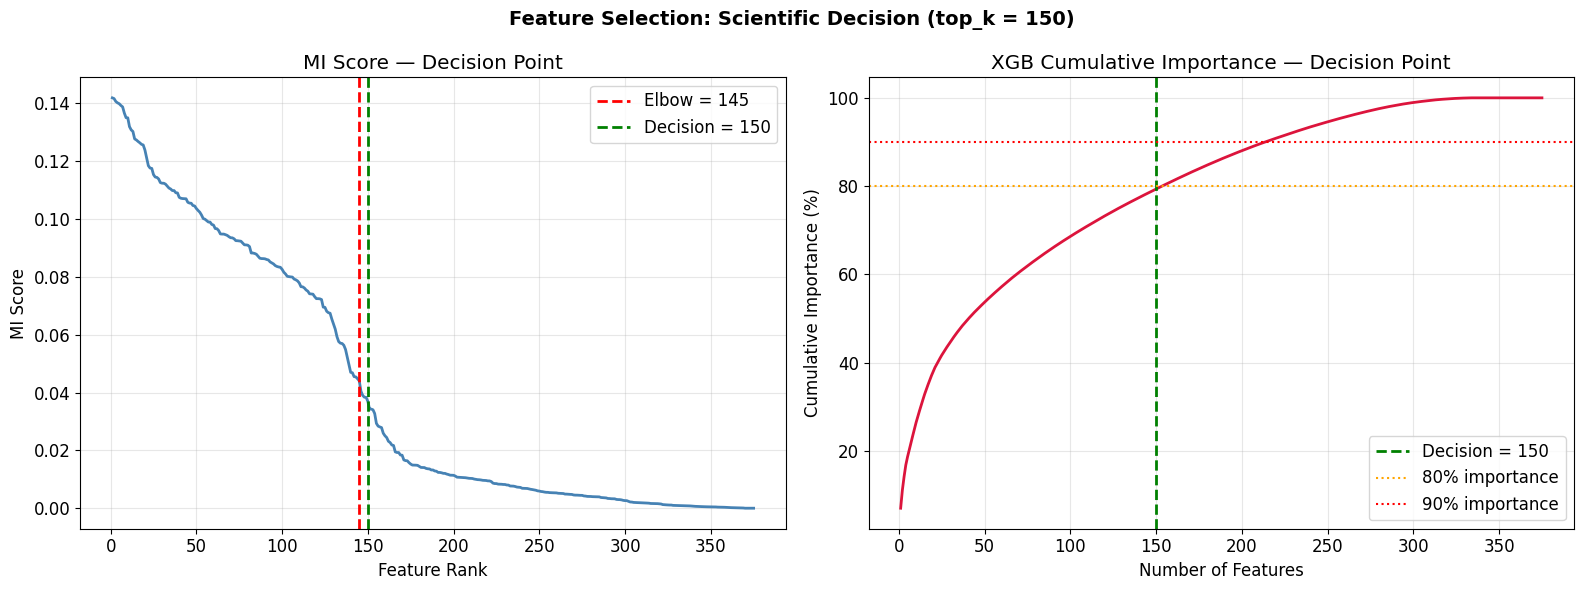

ACTION: Update feature_selector.py → top_k = 150
ACTION: Update configs/config.yaml → top_k: 150


In [6]:
print("=" * 60)
print("SCIENTIFIC FEATURE SELECTION DECISION")
print("=" * 60)

print("""
XGBoost Cumulative Importance:
  80% coverage → 154 features
  90% coverage → 214 features
  95% coverage → 254 features

Mutual Information:
  80% coverage → 123 features
  90% coverage → 153 features
  95% coverage → 195 features
  Elbow point  → 145 features

DECISION ANALYSIS:
  - MI elbow point        : 145  (sharp drop after this)
  - MI 90% coverage       : 153  (most information captured)
  - XGB 80% coverage      : 154  (most predictive power)
  - Average of three      : 150  (balanced)

FINAL DECISION: top_k = 150
  Reasoning:
  1. MI elbow at 145 — adding features beyond this gives
     diminishing returns in mutual information
  2. XGB 80% coverage at 154 — top 154 features carry
     80% of total tree-based predictive signal
  3. Union of MI(150) + XGB(150) → ~190-200 final features
     This is scientifically justified and not arbitrary
""")

# Visualize the decision
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MI curve with decision line
axes[0].plot(range(1, len(mi_series)+1), mi_series.values, color='steelblue', linewidth=2)
axes[0].axvline(x=145, color='red',    linestyle='--', linewidth=2, label='Elbow = 145')
axes[0].axvline(x=150, color='green',  linestyle='--', linewidth=2, label='Decision = 150')
axes[0].set_title('MI Score — Decision Point')
axes[0].set_xlabel('Feature Rank')
axes[0].set_ylabel('MI Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# XGB cumulative with decision line
xgb_cumulative = importance.cumsum() / importance.sum() * 100
axes[1].plot(range(1, len(xgb_cumulative)+1), xgb_cumulative.values,
             color='crimson', linewidth=2)
axes[1].axvline(x=150, color='green',  linestyle='--', linewidth=2, label='Decision = 150')
axes[1].axhline(y=80,  color='orange', linestyle=':', linewidth=1.5, label='80% importance')
axes[1].axhline(y=90,  color='red',    linestyle=':', linewidth=1.5, label='90% importance')
axes[1].set_title('XGB Cumulative Importance — Decision Point')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Feature Selection: Scientific Decision (top_k = 150)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("ACTION: Update feature_selector.py → top_k = 150")
print("ACTION: Update configs/config.yaml → top_k: 150")